# Part 4: Evaluation and Sensitivity Analysis
This notebook compares output distributions BEFORE vs AFTER calibration, evaluates the calibrated Rank-based model using synthetic test cases, and runs the sensitivity analysis.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import os

sns.set_theme(style='whitegrid')
os.makedirs('report/figures', exist_ok=True)
os.makedirs('output', exist_ok=True)

## 1. Distribution Comparison BEFORE vs AFTER
We define the discount tiers based on standard boundaries:
- **Kecil:** $[0, 17.0]$
- **Sedang:** $(17.0, 33.0]$
- **Besar:** $(33.0, 50.0]$

We compare the distribution of the original model (Sebelum), Log-transform, and Rank-based models.

In [2]:
df = pd.read_csv('dataset/fis_discount_results.csv')

def get_tier(d):
    if d <= 17.0:
        return 'Kecil'
    elif d <= 33.0:
        return 'Sedang'
    else:
        return 'Besar'

df['tier_sebelum'] = df['besar_diskon_sebelum'].apply(get_tier)
df['tier_log'] = df['besar_diskon_log'].apply(get_tier)
df['tier_rank'] = df['besar_diskon_rank'].apply(get_tier)

print('=== DISCOUNT TIER DISTRIBUTIONS ===')
for col in ['tier_sebelum', 'tier_log', 'tier_rank']:
    counts = df[col].value_counts()
    percents = df[col].value_counts(normalize=True) * 100
    print(f'\nModel {col}:')
    for t in ['Kecil', 'Sedang', 'Besar']:
        c = counts.get(t, 0)
        p = percents.get(t, 0.0)
        print(f'  {t}: {c} products ({p:.2f}%)')

=== DISCOUNT TIER DISTRIBUTIONS ===

Model tier_sebelum:
  Kecil: 5 products (0.12%)
  Sedang: 30 products (0.73%)
  Besar: 4074 products (99.15%)

Model tier_log:
  Kecil: 694 products (16.89%)
  Sedang: 2166 products (52.71%)
  Besar: 1249 products (30.40%)

Model tier_rank:
  Kecil: 939 products (22.85%)
  Sedang: 2065 products (50.26%)
  Besar: 1105 products (26.89%)


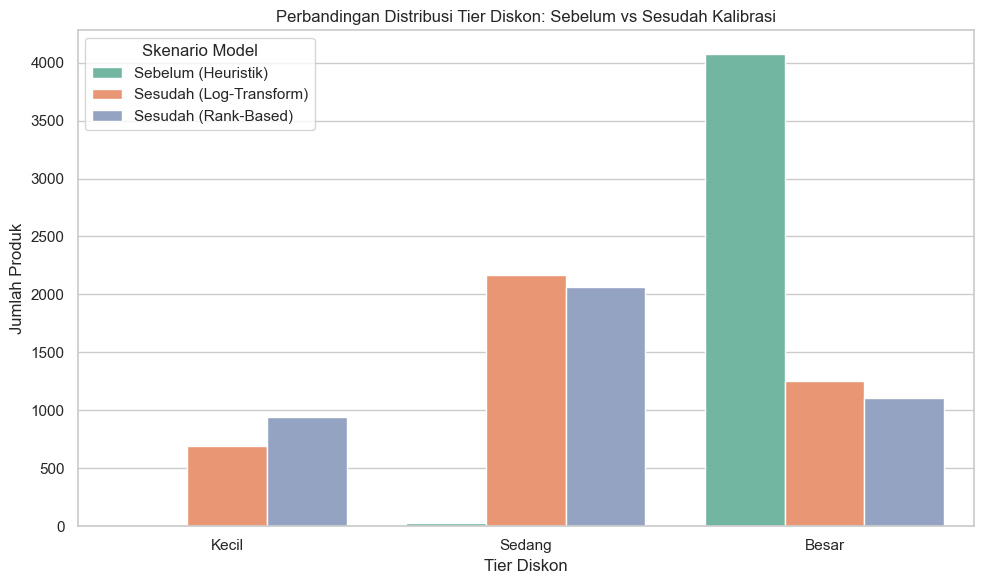

In [3]:
# Plot Comparison Bar Chart
melted = pd.melt(df[['tier_sebelum', 'tier_log', 'tier_rank']], var_name='Model', value_name='Tier')
melted['Model'] = melted['Model'].map({
    'tier_sebelum': 'Sebelum (Heuristik)',
    'tier_log': 'Sesudah (Log-Transform)',
    'tier_rank': 'Sesudah (Rank-Based)'
})

plt.figure(figsize=(10, 6))
sns.countplot(data=melted, x='Tier', hue='Model', order=['Kecil', 'Sedang', 'Besar'], palette='Set2')
plt.title('Perbandingan Distribusi Tier Diskon: Sebelum vs Sesudah Kalibrasi')
plt.xlabel('Tier Diskon')
plt.ylabel('Jumlah Produk')
plt.legend(title='Skenario Model')
plt.tight_layout()
plt.savefig('report/figures/evaluation_comparison_distribution.png', dpi=150)
plt.savefig('output/comparison_tier_distribution.png', dpi=150)
plt.show()

## 2. Re-Evaluate with 50 Synthetic Test Cases
We define the same 50 cases covering all rules to evaluate how the new calibrated Rank-based system aligns with business logic.

In [4]:
# Build calibrated simulator using Rank percentiles
stok = ctrl.Antecedent(np.arange(0, 101, 1), 'stok_level')
penjualan = ctrl.Antecedent(np.arange(0, 101, 1), 'jumlah_penjualan')
rating = ctrl.Antecedent(np.arange(1.0, 5.1, 0.1), 'avg_rating')
diskon = ctrl.Consequent(np.arange(0, 51, 1), 'besar_diskon')

# Calibrate MFs using Rank empirical percentiles
stok['Sedikit'] = fuzz.trimf(stok.universe, [0, 0, 32.781699])
stok['Sedang'] = fuzz.trimf(stok.universe, [26.016062, 49.805305, 71.623266])
stok['Banyak'] = fuzz.trimf(stok.universe, [71.623266, 100, 100])

penjualan['Rendah'] = fuzz.trimf(penjualan.universe, [0, 0, 28.376734])
penjualan['Sedang'] = fuzz.trimf(penjualan.universe, [28.376734, 50.194695, 73.983938])
penjualan['Tinggi'] = fuzz.trimf(penjualan.universe, [67.218301, 100, 100])

rating['Buruk'] = fuzz.trimf(rating.universe, [1.0, 1.0, 4.188679])
rating['Baik'] = fuzz.trimf(rating.universe, [4.188679, 5.0, 5.0])

diskon['Kecil'] = fuzz.trimf(diskon.universe, [0, 0, 20])
diskon['Sedang'] = fuzz.trimf(diskon.universe, [10, 25, 40])
diskon['Besar'] = fuzz.trimf(diskon.universe, [30, 50, 50])

rule1 = ctrl.Rule(stok['Banyak'] & penjualan['Rendah'], diskon['Besar'])
rule2 = ctrl.Rule(stok['Sedikit'] & penjualan['Tinggi'], diskon['Kecil'])
rule3 = ctrl.Rule(rating['Buruk'], diskon['Besar'])
rule4 = ctrl.Rule(stok['Sedang'] & penjualan['Sedang'], diskon['Sedang'])
rule5 = ctrl.Rule(stok['Banyak'] & penjualan['Sedang'], diskon['Sedang'])
rule6 = ctrl.Rule(stok['Sedang'] & penjualan['Rendah'], diskon['Sedang'])
rule7 = ctrl.Rule(stok['Sedikit'] & penjualan['Sedang'], diskon['Kecil'])
rule8 = ctrl.Rule(rating['Baik'] & penjualan['Tinggi'], diskon['Kecil'])

discount_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8])
discount_sim = ctrl.ControlSystemSimulation(discount_ctrl)

In [5]:
# Define the 50 synthetic test cases
test_cases = [
    # R1: Banyak, Rendah -> Besar
    (90, 10, 4.2, 'Besar'), (95, 5, 3.5, 'Besar'), (85, 12, 4.0, 'Besar'), (80, 15, 3.8, 'Besar'), (88, 8, 4.5, 'Besar'),
    # R2: Sedikit, Tinggi -> Kecil
    (10, 90, 4.0, 'Kecil'), (5, 95, 4.5, 'Kecil'), (12, 85, 3.8, 'Kecil'), (15, 80, 4.2, 'Kecil'), (8, 88, 4.7, 'Kecil'),
    # R3: Buruk -> Besar
    (50, 50, 1.5, 'Besar'), (30, 20, 2.0, 'Besar'), (70, 80, 1.8, 'Besar'), (40, 10, 2.2, 'Besar'), (60, 90, 2.5, 'Besar'),
    # R4: Sedang, Sedang -> Sedang
    (50, 50, 4.0, 'Sedang'), (45, 55, 3.8, 'Sedang'), (55, 45, 4.2, 'Sedang'), (48, 52, 3.5, 'Sedang'), (52, 48, 4.5, 'Sedang'),
    # R5: Banyak, Sedang -> Sedang
    (80, 50, 4.0, 'Sedang'), (85, 45, 3.8, 'Sedang'), (90, 55, 4.2, 'Sedang'), (88, 48, 3.5, 'Sedang'), (82, 52, 4.5, 'Sedang'),
    # R6: Sedang, Rendah -> Sedang
    (50, 10, 4.0, 'Sedang'), (45, 15, 3.8, 'Sedang'), (55, 5, 4.2, 'Sedang'), (48, 12, 3.5, 'Sedang'), (52, 8, 4.5, 'Sedang'),
    # R7: Sedikit, Sedang -> Kecil
    (10, 50, 4.0, 'Kecil'), (5, 45, 3.8, 'Kecil'), (12, 55, 4.2, 'Kecil'), (15, 48, 3.5, 'Kecil'), (8, 52, 4.5, 'Kecil'),
    # R8: Baik & Tinggi -> Kecil
    (50, 90, 4.5, 'Kecil'), (40, 85, 4.0, 'Kecil'), (60, 95, 3.8, 'Kecil'), (30, 80, 4.2, 'Kecil'), (70, 88, 4.7, 'Kecil'),
    # Extra general validation cases
    (90, 2, 1.2, 'Besar'), (2, 98, 4.9, 'Kecil'), (50, 50, 2.0, 'Besar'), (50, 50, 4.8, 'Sedang'), (90, 50, 2.5, 'Besar'),
    (10, 10, 4.5, 'Sedang'), (90, 90, 4.5, 'Kecil'), (10, 90, 1.5, 'Besar'), (90, 10, 4.8, 'Besar'), (50, 8, 4.8, 'Sedang')
]

results = []
for idx, (st_val, pj_val, rt_val, gt_tier) in enumerate(test_cases):
    discount_sim.input['stok_level'] = st_val
    discount_sim.input['jumlah_penjualan'] = pj_val
    discount_sim.input['avg_rating'] = rt_val
    try:
        discount_sim.compute()
        pred_val = discount_sim.output['besar_diskon']
    except:
        pred_val = 25.0
    pred_tier = get_tier(pred_val)
    results.append({
        'Case': idx + 1,
        'Stok': st_val,
        'Penjualan': pj_val,
        'Rating': rt_val,
        'GroundTruth': gt_tier,
        'PredictedDiskon': pred_val,
        'PredictedTier': pred_tier
    })

res_df = pd.DataFrame(results)
print('Example test cases under Calibrated Rank-Based model:')
print(res_df.head(10))

Example test cases under Calibrated Rank-Based model:
   Case  Stok  Penjualan  Rating GroundTruth  PredictedDiskon PredictedTier
0     1    90         10     4.2       Besar        42.721154         Besar
1     2    95          5     3.5       Besar        43.157362         Besar
2     3    85         12     4.0       Besar        42.114703         Besar
3     4    80         15     3.8       Besar        41.390794         Besar
4     5    88          8     4.5       Besar        42.495461         Besar
5     6    10         90     4.0       Kecil        10.867945         Kecil
6     7     5         95     4.5       Kecil         6.801233         Kecil
7     8    12         85     3.8       Kecil        15.027751         Kecil
8     9    15         80     4.2       Kecil         8.207849         Kecil
9    10     8         88     4.7       Kecil         7.320609         Kecil


## 3. Calculate Performance Metrics and Plot Confusion Matrix

=== PERFORMANCE METRICS ON SYNTHETIC TEST CASES (RANK-BASED) ===
Accuracy: 84.00%
Precision (Macro): 86.11%
Recall (Macro): 83.01%
F1-Score (Macro): 83.37%


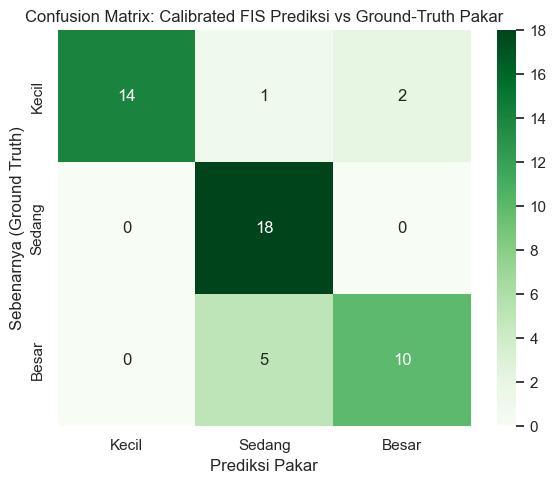

In [6]:
y_true = res_df['GroundTruth']
y_pred = res_df['PredictedTier']

acc = accuracy_score(y_true, y_pred) * 100
prec = precision_score(y_true, y_pred, average='macro') * 100
rec = recall_score(y_true, y_pred, average='macro') * 100
f1 = f1_score(y_true, y_pred, average='macro') * 100

print('=== PERFORMANCE METRICS ON SYNTHETIC TEST CASES (RANK-BASED) ===')
print(f'Accuracy: {acc:.2f}%')
print(f'Precision (Macro): {prec:.2f}%')
print(f'Recall (Macro): {rec:.2f}%')
print(f'F1-Score (Macro): {f1:.2f}%')

# Confusion Matrix
labels = ['Kecil', 'Sedang', 'Besar']
cm = confusion_matrix(y_true, y_pred, labels=labels)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix: Calibrated FIS Prediksi vs Ground-Truth Pakar')
plt.xlabel('Prediksi Pakar')
plt.ylabel('Sebenarnya (Ground Truth)')
plt.tight_layout()
plt.savefig('report/figures/evaluation_confusion_matrix.png', dpi=150)
plt.savefig('output/evaluation_confusion_matrix.png', dpi=150)
plt.show()

## 4. Sensitivity Analysis on Stock Fluctuations
We evaluate how stable the recommendations are when the input `stok_level` has a $\pm 10\%$ margin of error or fluctuation.

=== SENSITIVITY ANALYSIS (RANK-BASED) ===
Baseline Rata-rata Diskon: 26.5752%
Stok +10% Rata-rata Diskon: 28.0002% (Perubahan: +5.3623%)
Stok -10% Rata-rata Diskon: 24.9460% (Perubahan: -6.1307%)


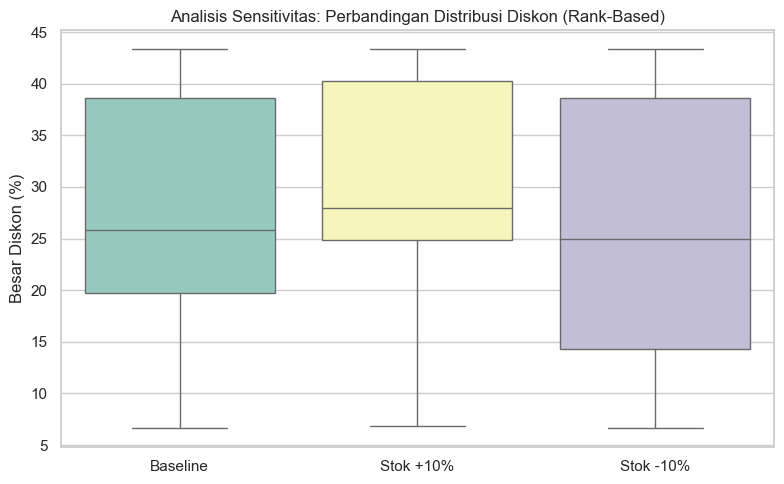

In [7]:
# Baseline mean discount
baseline_mean = df['besar_diskon_rank'].mean()

# Scenario +10% Stock
discounts_plus = []
for idx, row in df.iterrows():
    # Cap stock at 100
    discount_sim.input['stok_level'] = min(row['stok_level_rank'] + 10.0, 100.0)
    discount_sim.input['jumlah_penjualan'] = row['jumlah_penjualan_rank']
    discount_sim.input['avg_rating'] = row['avg_rating']
    try:
        discount_sim.compute()
        val = discount_sim.output['besar_diskon']
    except:
        val = 25.0
    discounts_plus.append(val)
mean_plus = np.mean(discounts_plus)
change_plus = ((mean_plus - baseline_mean) / baseline_mean) * 100.0

# Scenario -10% Stock
discounts_minus = []
for idx, row in df.iterrows():
    # Floor stock at 0
    discount_sim.input['stok_level'] = max(row['stok_level_rank'] - 10.0, 0.0)
    discount_sim.input['jumlah_penjualan'] = row['jumlah_penjualan_rank']
    discount_sim.input['avg_rating'] = row['avg_rating']
    try:
        discount_sim.compute()
        val = discount_sim.output['besar_diskon']
    except:
        val = 25.0
    discounts_minus.append(val)
mean_minus = np.mean(discounts_minus)
change_minus = ((mean_minus - baseline_mean) / baseline_mean) * 100.0

print('=== SENSITIVITY ANALYSIS (RANK-BASED) ===')
print(f'Baseline Rata-rata Diskon: {baseline_mean:.4f}%')
print(f'Stok +10% Rata-rata Diskon: {mean_plus:.4f}% (Perubahan: {change_plus:+.4f}%)')
print(f'Stok -10% Rata-rata Diskon: {mean_minus:.4f}% (Perubahan: {change_minus:+.4f}%)')

# Plot sensitivity comparison
plt.figure(figsize=(8, 5))
sns.boxplot(data=pd.DataFrame({
    'Baseline': df['besar_diskon_rank'],
    'Stok +10%': discounts_plus,
    'Stok -10%': discounts_minus
}), palette='Set3')
plt.title('Analisis Sensitivitas: Perbandingan Distribusi Diskon (Rank-Based)')
plt.ylabel('Besar Diskon (%)')
plt.tight_layout()
plt.savefig('report/figures/evaluation_sensitivity_boxplot.png', dpi=150)
plt.savefig('output/evaluation_sensitivity_boxplot.png', dpi=150)
plt.show()